In [1]:
# Env
NUM_AGENTS = 2
HEIGHT = 6
WIDTH = 6
SPAWN_PROB_PER_CELL = 0.05
DESPAWN_PROB_PER_CELL = 0.09

# Training
ENV_ITERATIONS = 100
DISCOUNT = 0.99
EPSILON = 0.1
LEARNING_RATE = 0.00002
BATCH_SIZE = 32
TARGET_UPDATE_FREQUENCY = 100

# Model
CONV_CHANNELS = [16, 32]
HIDDEN_FEATURES = 128
HIDDEN_LAYERS = 2
KERNEL_SIZE = 3


In [2]:
import sys
sys.path.append('../../../')
from models.value_cnn import ValueCNNDecentralized, ValueCNNCentralized
import torch
from tadd_helpers.env_functions import State
import numpy as np
import pickle
import matplotlib.pyplot as plt
from tqdm import tqdm

--- PyTorch is configured to use: cuda ---


In [3]:
decentralized_model_2a_path = "decentralized_model6x6_agents2/decentralized_value_cnn_agent_i.pt"
decentralized_model_2a_paths = []
for i in range(2):
    decentralized_model_2a_paths.append(decentralized_model_2a_path.replace(f"agent_i", f"agent_{i}"))
print(decentralized_model_2a_paths)

centralized_model_2a_path = "centralized_model6x6_agents2/centralized_value_cnn.pt"

['decentralized_model6x6_agents2/decentralized_value_cnn_agent_0.pt', 'decentralized_model6x6_agents2/decentralized_value_cnn_agent_1.pt']


In [4]:
decentralized_2a_cnns: list[ValueCNNDecentralized] = []
for i in range(len(decentralized_model_2a_paths)):
    model_path = decentralized_model_2a_paths[i]
    cnn = ValueCNNDecentralized(HEIGHT, WIDTH, LEARNING_RATE, DISCOUNT, HIDDEN_FEATURES, HIDDEN_LAYERS, CONV_CHANNELS, KERNEL_SIZE)
    cnn.load_state_dict(torch.load(model_path))
    cnn.eval()
    decentralized_2a_cnns.append(cnn)
centralized_2a_cnn = ValueCNNCentralized(HEIGHT, WIDTH, LEARNING_RATE, DISCOUNT, HIDDEN_FEATURES, HIDDEN_LAYERS, CONV_CHANNELS, KERNEL_SIZE)
centralized_2a_cnn.load_state_dict(torch.load(centralized_model_2a_path))
centralized_2a_cnn.eval()


ValueCNNCentralized(
  (conv_layers): ModuleList(
    (0): Conv2d(2, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (mlp_head): Sequential(
    (0): Linear(in_features=32, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=1, bias=True)
  )
  (target_net): CNNCentralized(
    (conv_layers): ModuleList(
      (0): Conv2d(2, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU()
      (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): ReLU()
      (5): Max

In [5]:
apples = np.array(
    [[1, 0, 0, 0, 0, 0],
     [0, 0, 0, 0, 0, 0],
     [0, 0, 0, 0, 0, 0],
     [0, 0, 0, 0, 0, 0],
     [0, 0, 0, 0, 0, 0],
     [0, 0, 0, 0, 0, 0]]
)
agents = {0: (0, 0), 1: (5, 5)}
state = State(_apples=apples, _agents=agents)
print(state)

--- State (Grid: 6x6) ---

--- Agent Locations ---
  Agent 0: (0, 0)
  Agent 1: (5, 5)

--- Agents (Count) ---
1 . . . . .
. . . . . .
. . . . . .
. . . . . .
. . . . . .
. . . . . 1

--- Apples (Count) ---
1 . . . . .
. . . . . .
. . . . . .
. . . . . .
. . . . . .
. . . . . .


In [6]:
val_d = []
for i in range(NUM_AGENTS):
    cnn = decentralized_2a_cnns[i]
    raw_dict = cnn.state_to_raw_dict(state)
    pred_value = cnn.get_model_reward_prediction_from_raw(raw_dict, agent_pos=state.agent_position(i))
    val_d.append(pred_value)
    
for i in range(NUM_AGENTS):
    print(f"Agent {i} predicted value: {val_d[i]}")

Agent 0 predicted value: [[11.464035]]
Agent 1 predicted value: [[14.022793]]


In [7]:
valC = centralized_2a_cnn.get_model_reward_prediction_from_raw(centralized_2a_cnn.state_to_raw_dict(state)).item()
print(f"Centralized predicted value: {valC}")

Centralized predicted value: 26.84612464904785


In [19]:
states: list[State] = []
states_file_path = "centralized_model6x6_agents2/trained_states_centralized.pkl"
with open(states_file_path, "rb") as f:
    states = pickle.load(f)
print(states[:3])

[State(_apples=array([[0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0]]), _agents={0: (3, 4), 1: (2, 4)}, name='Empty State'), State(_apples=array([[0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0]]), _agents={0: (3, 4), 1: (np.int64(1), np.int64(4))}, name='Empty State'), State(_apples=array([[0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 1, 0],
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 1, 0]]), _agents={0: (3, 4), 1: (np.int64(1), np.int64(4))}, name='Empty State')]


In [20]:
print(len(states))

800000


In [45]:
decentralized_predicted_team_values = []
centralized_predicted_values = []
eval_states = states[400000:400000 + 100]
print(len(eval_states))


100


In [46]:
for state in tqdm(eval_states):
    val_d = []
    for i in range(NUM_AGENTS):
        cnn = decentralized_2a_cnns[i]
        raw_dict = cnn.state_to_raw_dict(state)
        pred_value = cnn.get_model_reward_prediction_from_raw(raw_dict, agent_pos=state.agent_position(i))
        val_d.append(pred_value.item())
        
    valC = centralized_2a_cnn.get_model_reward_prediction_from_raw(centralized_2a_cnn.state_to_raw_dict(state)).item()
    
    val_d_team = sum(val_d)
    decentralized_predicted_team_values.append(val_d_team)
    centralized_predicted_values.append(valC)

  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [00:01<00:00, 90.81it/s]


In [47]:
print(decentralized_predicted_team_values[:10])
print(centralized_predicted_values[:10])

[29.13936996459961, 29.45830535888672, 28.729475021362305, 28.650449752807617, 28.20040225982666, 28.497570037841797, 29.743897438049316, 29.976696968078613, 29.4187650680542, 29.96122932434082]
[29.216968536376953, 29.464834213256836, 28.715492248535156, 29.209497451782227, 28.347719192504883, 28.540922164916992, 29.14920425415039, 29.76443099975586, 29.39427375793457, 29.595502853393555]


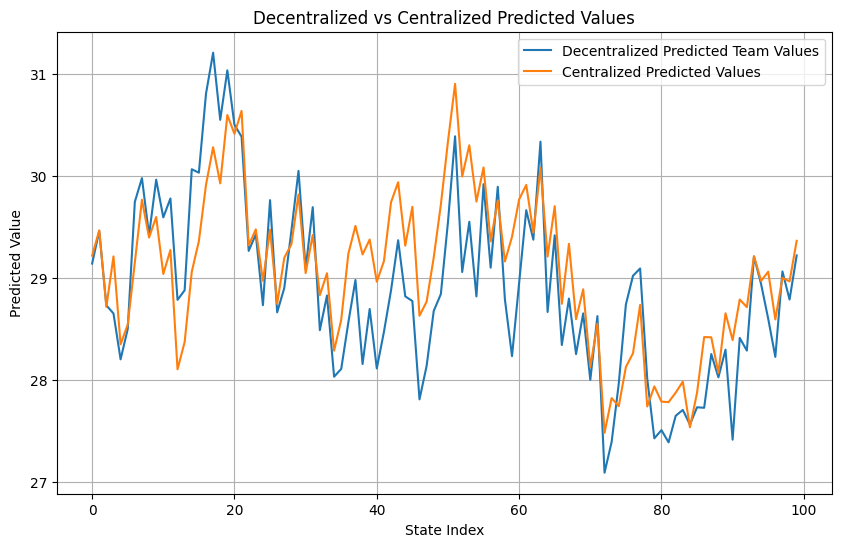

In [48]:
plt.figure(figsize=(10, 6))
plt.plot(decentralized_predicted_team_values, label='Decentralized Predicted Team Values')
plt.plot(centralized_predicted_values, label='Centralized Predicted Values')
plt.xlabel('State Index')
plt.ylabel('Predicted Value')
plt.title('Decentralized vs Centralized Predicted Values')
plt.legend()
plt.grid()
plt.show()

29.070009784698485
MAE: 0.41517455101013184
Max Difference: 1.004964828491211
Min Difference: -1.1698541641235352


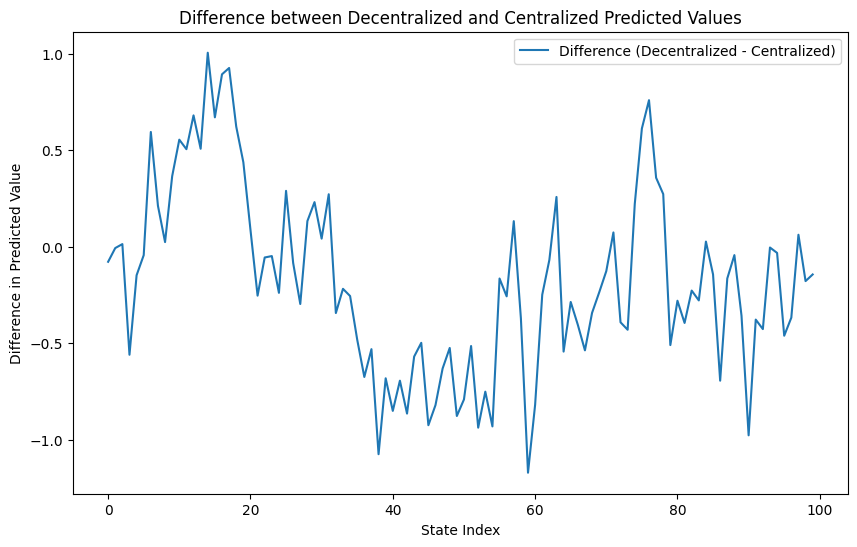

In [49]:
decentralized_np = np.array(decentralized_predicted_team_values)
centralized_np = np.array(centralized_predicted_values)
print(np.mean(centralized_np))
diff = decentralized_np - centralized_np
# plot diff
plt.figure(figsize=(10, 6))
plt.plot(diff, label='Difference (Decentralized - Centralized)')
plt.xlabel('State Index')
plt.ylabel('Difference in Predicted Value')
plt.title('Difference between Decentralized and Centralized Predicted Values')
plt.legend()

mae = np.mean(np.abs(diff))
max_diff = np.max(diff)
min_diff = np.min(diff)
print(f"MAE: {mae}")
print(f"Max Difference: {max_diff}")
print(f"Min Difference: {min_diff}")